 Imports

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
import joblib
import os

 Data Loading

In [12]:
import os
import pandas as pd

base_path = os.path.dirname(os.getcwd())  # parent folder of notebook
file_path = os.path.join(base_path, "AI project", "UNSW_NB15_training-set.csv")

df = pd.read_csv(file_path)
print(f"Data loaded successfully. Shape: {df.shape}")


Data loaded successfully. Shape: (82332, 45)


Preprocessing

In [13]:
X = df.drop(columns=['id', 'label', 'attack_cat'], errors='ignore')
categorical_cols = X.select_dtypes(include=['object']).columns
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

Scaling & Saving Scaler

In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
joblib.dump(scaler, '../models/scaler.pkl')
print("StandardScaler saved in models folder.")

StandardScaler saved in models folder.


K-Means Training & Serialization

In [15]:
print("Training K-Means Model...")
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(X_scaled)
joblib.dump(kmeans, '../models/kmeans_model.pkl')
print("K-Means Model saved successfully.")

Training K-Means Model...
K-Means Model saved successfully.


Visualizing Clusters Graph

Fit KMeans model

In [17]:
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_scaled) 

Now plotting will work

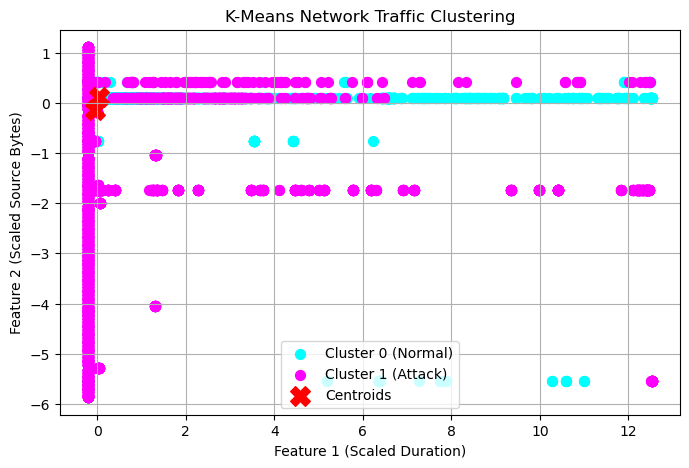

In [18]:


plt.figure(figsize=(8, 5))
plt.scatter(X_scaled[clusters == 0, 0], X_scaled[clusters == 0, 1], 
            s=50, c='cyan', label='Cluster 0 (Normal)')
plt.scatter(X_scaled[clusters == 1, 0], X_scaled[clusters == 1, 1], 
            s=50, c='magenta', label='Cluster 1 (Attack)')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
            s=200, c='red', marker='X', label='Centroids')
plt.title('K-Means Network Traffic Clustering')
plt.xlabel('Feature 1 (Scaled Duration)')
plt.ylabel('Feature 2 (Scaled Source Bytes)')
plt.legend()
plt.grid(True)
plt.show()
